In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("Mall_Customers.csv")

In [ ]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
data.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [ ]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
data.isnull().sum().any()

np.False_

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data = data.drop(columns=[data.columns[0]])

feature selection

In [ ]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

checking outliers

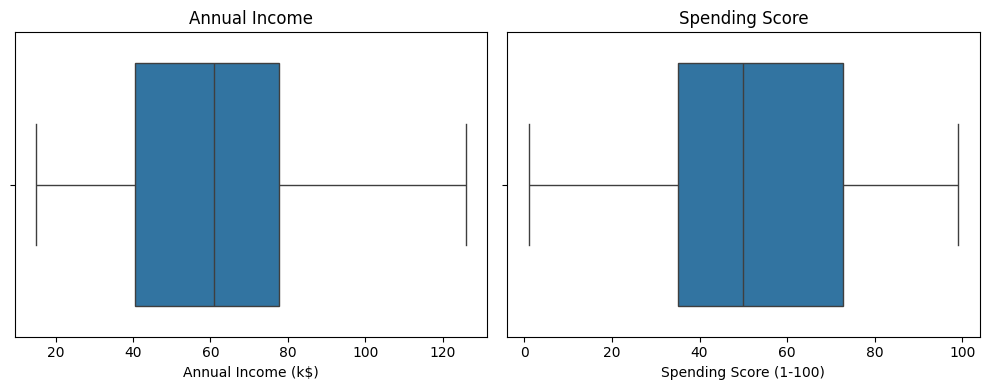

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=data['Annual Income (k$)'])
plt.title("Annual Income")

plt.subplot(1,2,2)
sns.boxplot(x=data['Spending Score (1-100)'])
plt.title("Spending Score")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

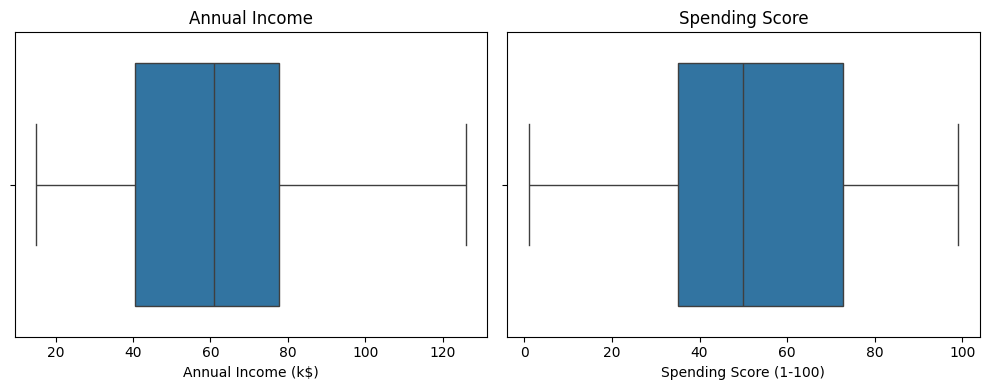

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=data['Annual Income (k$)'])
plt.title("Annual Income")

plt.subplot(1,2,2)
sns.boxplot(x=data['Spending Score (1-100)'])
plt.title("Spending Score")

plt.tight_layout()
plt.show()

correlation

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = data.select_dtypes(include=['int64','float64'])
num_cols.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


In [ ]:
corr = num_cols.corr()
corr

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.017285,0.984367,0.013840
Age,-0.017285,1.000000,0.004406,-0.329421
Annual Income (k$),0.984367,0.004406,1.000000,0.010080
Spending Score (1-100),0.013840,-0.329421,0.010080,1.000000


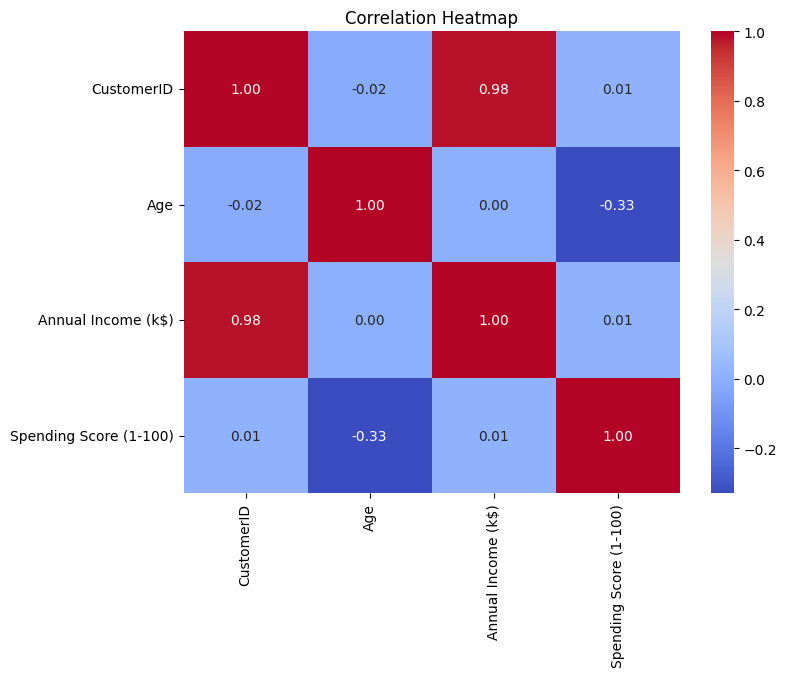

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

Visualize Raw Data

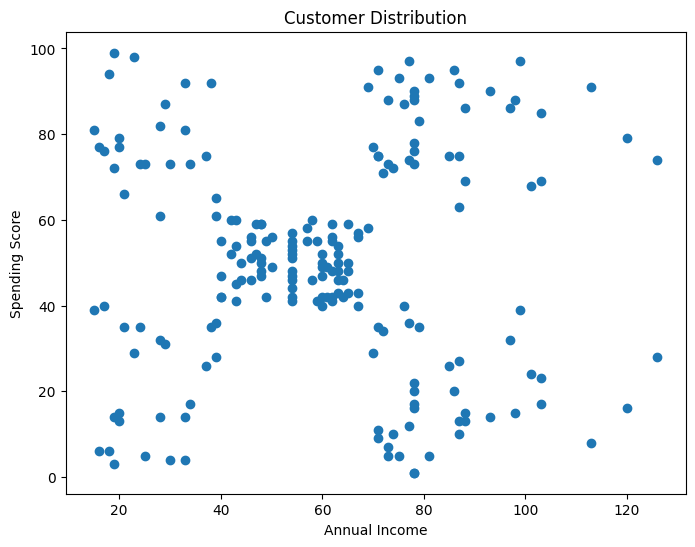

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Elbow Method

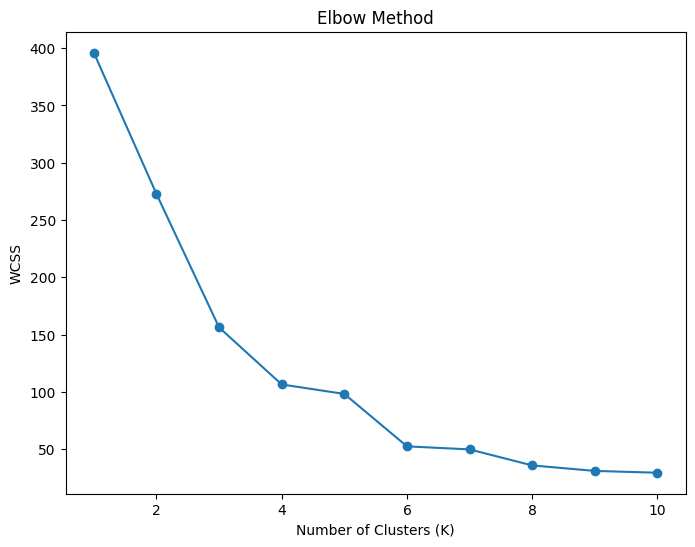

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
model = KMeans(n_clusters=5, random_state=42)
clusters = model.fit_predict(X_scaled)

data['Cluster'] = clusters

Visualize Clusters

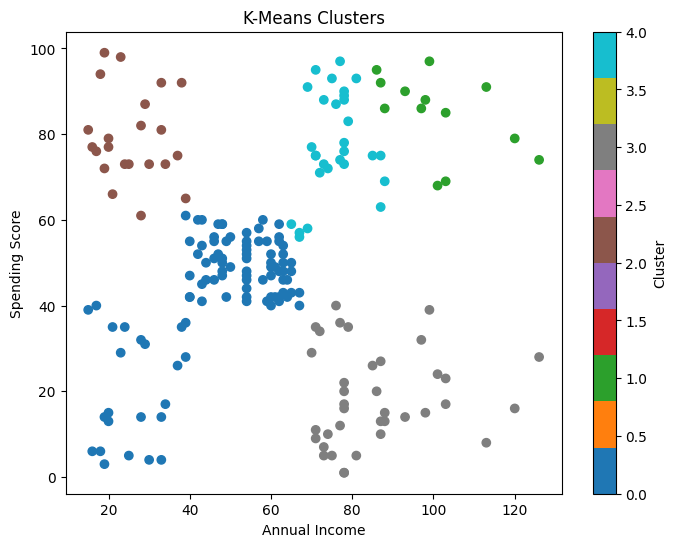

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=data['Cluster'],
    cmap='tab10'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clusters")
plt.colorbar(label="Cluster")
plt.show()

Plot Cluster Centers

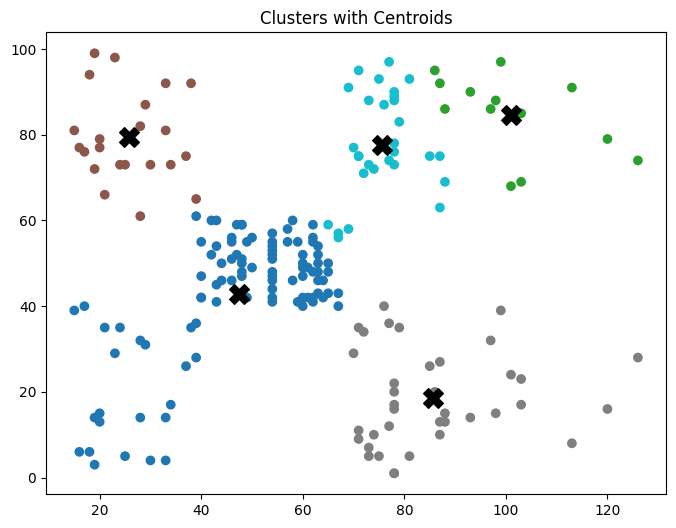

In [ ]:
centers = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=data['Cluster'],
    cmap='tab10'
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='black',
    marker='X',
    s=200
)

plt.title("Clusters with Centroids")
plt.show()

Evaluate Using Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.43661309494625056
